In [ ]:
#import
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch
from collections import defaultdict
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)

In [44]:
#define path to radiology folder
MRI_folder = Path("radiology")

In [49]:
#paths to mha files
mha_paths = list(MRI_folder.rglob("*.mha"))
print("Number of .mha files:", len(mha_paths))
print("Example Path:", mha_paths[0])

#group them by parent folder
by_parent = defaultdict(list)
for p in mha_paths:
    by_parent[p.parent].append(p)

def classify_mri(name: str):
    n = name.lower()
    if "adc" in n: return "adc"
    if "hbv" in n or "high" in n: return "hbv"
    if "t2" in n: return "t2w"
    if "mask" in n or "seg" in n: return "mask"
    return None

#list of folders with all 4 .mha files in them
complete_folders = []
for parent, files in by_parent.items():
    mods = {classify_mri(f.name) for f in files}
    if {"adc","hbv","t2w","mask"}.issubset(mods):
        complete_folders.append(parent)

print("Folders with adc/hbv/t2w/mask files:", len(complete_folders))


Number of .mha files: 380
Example Path: radiology/images/1264/1264_0001_adc.mha
Folders with adc/hbv/t2w/mask files: 95


In [ ]:
#matches files to mri type
def pick_file(files, mri_type):
    for f in files:
        if classify_mri(f.name) == mri_type:
            return f
    return None

cases = []
for folder in sorted(complete_folders):
    files = by_parent[folder]
    row = {
        "case_folder": str(folder),
        "adc_path": str(pick_file(files, "adc")),
        "hbv_path": str(pick_file(files, "hbv")),
        "t2w_path": str(pick_file(files, "t2w")),
        "mask_path": str(pick_file(files, "mask")),
    }
    row["case_id"] = folder.name
    cases.append(row)

#create a dataframe for file paths
cases_df = pd.DataFrame(cases)
display(cases_df.head())
print("Total cases:", len(cases_df))

,case_folder,adc_path,hbv_path,t2w_path,mask_path,case_id
0,radiology/images/1003,radiology/images/1003/1003_0001_adc.mha,radiology/images/1003/1003_0001_hbv.mha,radiology/images/1003/1003_0001_t2w.mha,radiology/images/1003/1003_0001_mask.mha,1003
1,radiology/images/1010,radiology/images/1010/1010_0001_adc.mha,radiology/images/1010/1010_0001_hbv.mha,radiology/images/1010/1010_0001_t2w.mha,radiology/images/1010/1010_0001_mask.mha,1010
2,radiology/images/1011,radiology/images/1011/1011_0001_adc.mha,radiology/images/1011/1011_0001_hbv.mha,radiology/images/1011/1011_0001_t2w.mha,radiology/images/1011/1011_0001_mask.mha,1011
3,radiology/images/1021,radiology/images/1021/1021_0001_adc.mha,radiology/images/1021/1021_0001_hbv.mha,radiology/images/1021/1021_0001_t2w.mha,radiology/images/1021/1021_0001_mask.mha,1021
4,radiology/images/1025,radiology/images/1025/1025_0001_adc.mha,radiology/images/1025/1025_0001_hbv.mha,radiology/images/1025/1025_0001_t2w.mha,radiology/images/1025/1025_0001_mask.mha,1025


Cases: 95


In [50]:
#resample high-res mask to match same graid as others
def resample_mask_to(reference_img, mask_img):
    return sitk.Resample(
        mask_img, 
        reference_img, 
        sitk.Transform(), 
        sitk.sitkNearestNeighbor,
        0, 
        sitk.sitkUInt8 
    )

#stats for images
def modality_stats(arr, mask=None):
    out = {}
    out["shape_z"], out["shape_y"], out["shape_x"] = map(int, arr.shape)
    out["min"] = float(np.min(arr))
    out["max"] = float(np.max(arr))
    out["mean"] = float(np.mean(arr))
    out["std"]  = float(np.std(arr))

    if mask is not None:
        mask = (mask > 0)
        out["roi_nvox"] = int(mask.sum())
        if out["roi_nvox"] == 0:
            out["roi_mean"] = np.nan
            out["roi_std"]  = np.nan
            for p in (1,5,25,50,75,95,99):
                out[f"roi_p{p}"] = np.nan
        else:
            roi = arr[mask]
            out["roi_mean"] = float(np.mean(roi))
            out["roi_std"]  = float(np.std(roi))
            for p in (1,5,25,50,75,95,99):
                out[f"roi_p{p}"] = float(np.percentile(roi, p))
    return out

In [51]:
rows = []
#loop through every folder
for _, r in cases_df.iterrows():
    out = {"case_id": r["case_id"], "case_folder": r["case_folder"]}
    try:
        #read images
        t2_img  = sitk.ReadImage(r["t2w_path"])
        adc_img = sitk.ReadImage(r["adc_path"])
        hbv_img = sitk.ReadImage(r["hbv_path"])
        msk_img = sitk.ReadImage(r["mask_path"])

        #convert to array
        t2  = sitk.GetArrayFromImage(t2_img)
        adc = sitk.GetArrayFromImage(adc_img)
        hbv = sitk.GetArrayFromImage(hbv_img)
        msk_t2 = sitk.GetArrayFromImage(msk_img)

        #resample mask to ADC/HBV grids
        msk_on_adc = sitk.GetArrayFromImage(resample_mask_to(adc_img, msk_img))
        msk_on_hbv = sitk.GetArrayFromImage(resample_mask_to(hbv_img, msk_img))

        #tumor volume in mm^3 computed on T2 grid
        sp = msk_img.GetSpacing()  # (x,y,z)
        voxel_vol_mm3 = float(sp[0] * sp[1] * sp[2])
        tumor_vox = int((msk_t2 > 0).sum())
        out["tumor_voxels"] = tumor_vox
        out["voxel_vol_mm3"] = voxel_vol_mm3
        out["tumor_vol_mm3"] = tumor_vox * voxel_vol_mm3

        #whole-image + ROI stats
        out.update({f"t2w_{k}": v for k, v in modality_stats(t2,  msk_t2).items()})
        out.update({f"adc_{k}": v for k, v in modality_stats(adc, msk_on_adc).items()})
        out.update({f"hbv_{k}": v for k, v in modality_stats(hbv, msk_on_hbv).items()})

        #ratios
        out["adc_roi_mean_over_whole_mean"] = out["adc_roi_mean"] / out["adc_mean"] if out["adc_mean"] else np.nan
        out["hbv_roi_mean_over_whole_mean"] = out["hbv_roi_mean"] / out["hbv_mean"] if out["hbv_mean"] else np.nan

    except Exception as e:
        out["error"] = str(e)

    rows.append(out)

#create dataframe of info
mri_stats_df = pd.DataFrame(rows)
display(mri_stats_df.head())
print("Rows total:", len(mri_stats_df))
print("Rows with errors:", mri_stats_df.get("error", pd.Series(dtype=object)).notna().sum())


,case_id,case_folder,tumor_voxels,voxel_vol_mm3,tumor_vol_mm3,t2w_shape_z,t2w_shape_y,t2w_shape_x,t2w_min,t2w_max,t2w_mean,t2w_std,t2w_roi_nvox,t2w_roi_mean,t2w_roi_std,t2w_roi_p1,t2w_roi_p5,t2w_roi_p25,t2w_roi_p50,t2w_roi_p75,t2w_roi_p95,t2w_roi_p99,adc_shape_z,adc_shape_y,adc_shape_x,adc_min,adc_max,adc_mean,adc_std,adc_roi_nvox,adc_roi_mean,adc_roi_std,adc_roi_p1,adc_roi_p5,adc_roi_p25,adc_roi_p50,adc_roi_p75,adc_roi_p95,adc_roi_p99,hbv_shape_z,hbv_shape_y,hbv_shape_x,hbv_min,hbv_max,hbv_mean,hbv_std,hbv_roi_nvox,hbv_roi_mean,hbv_roi_std,hbv_roi_p1,hbv_roi_p5,hbv_roi_p25,hbv_roi_p50,hbv_roi_p75,hbv_roi_p95,hbv_roi_p99,adc_roi_mean_over_whole_mean,hbv_roi_mean_over_whole_mean
0,1003,radiology/images/1003,118954,0.324000,38541.098042,19,640,640,0.0,1083.0,265.692827,184.338164,118954,239.742169,104.314197,79.0,113.0,169.0,215.0,284.0,465.0,558.0,19,128,120,0.0,4095.0,639.290543,616.027796,2688,1281.578125,390.659269,575.48,659.0,1013.00,1276.0,1513.25,2019.30,2228.00,19,128,120,0.0,232.0,10.974921,9.846328,2688,48.226190,22.435294,17.0,24.00,33.0,42.0,55.0,98.0,115.13,2.004688,4.394217
1,1010,radiology/images/1010,50515,0.532725,26910.591610,21,448,448,0.0,1473.0,41.690484,74.774502,50515,159.482649,78.740865,44.0,58.0,101.0,145.0,205.0,301.0,410.0,21,128,84,0.0,4095.0,249.135040,613.747994,2013,1290.539990,430.490132,470.60,591.6,969.00,1309.0,1600.00,1982.80,2224.24,21,128,84,0.0,79.0,1.330725,4.123688,2013,24.081967,13.615971,6.0,9.00,15.0,20.0,28.0,55.0,64.88,5.180082,18.096881
2,1011,radiology/images/1011,57787,0.750000,43340.250000,21,384,384,0.0,1040.0,210.155073,159.018624,57787,206.688875,89.890643,47.0,85.0,148.0,193.0,246.0,388.0,486.0,21,128,120,0.0,3555.0,598.828854,759.970778,3618,1422.074074,276.864380,863.34,1032.0,1237.25,1405.0,1585.00,1903.15,2133.66,21,128,120,0.0,144.0,5.449758,8.534833,3618,11.545882,3.470195,5.0,7.00,9.0,11.0,13.0,18.0,23.00,2.374759,2.118604
3,1021,radiology/images/1021,132049,0.324000,42783.881100,19,640,640,0.0,1496.0,367.491309,225.540352,132049,295.901370,116.037225,119.0,153.0,214.0,272.0,350.0,525.0,670.0,19,128,120,0.0,3735.0,628.254876,608.155235,2965,1398.524452,318.370877,712.64,846.8,1216.00,1400.0,1586.00,1941.20,2240.36,19,128,120,0.0,223.0,13.355339,10.764379,2965,42.699494,12.210178,17.0,25.00,35.0,41.0,50.0,65.0,76.00,2.226046,3.197185
4,1025,radiology/images/1025,20436,1.687500,34485.750000,19,256,256,0.0,1176.0,222.797906,163.452633,20436,229.847769,62.857773,109.0,137.0,186.0,223.0,268.0,344.0,400.0,19,128,120,0.0,3451.0,692.142085,605.980076,2884,1313.260749,249.645211,840.83,938.0,1121.00,1292.0,1490.00,1759.85,1919.34,19,128,120,0.0,88.0,7.946430,6.611668,2884,32.441054,9.612120,11.0,17.15,26.0,32.0,39.0,49.0,57.00,1.897386,4.082469


Rows total: 95
Rows with errors: 0


In [ ]:
#save CSV
OUT_CSV = MRI_folder / "mri_case_level_stats.csv"
mri_stats_df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

Saved: radiology/mri_case_level_stats.csv


In [ ]:
#look for .pt files
features_root = MRI_folder / "features"
pt_paths = list(features_root.rglob("*.pt")) if features_root.exists() else []
print("Found .pt files:", len(pt_paths))
print("Example:", pt_paths[0] if pt_paths else "None")

feat_rows = []
for p in pt_paths[:2000]: #up to 2000 in case there's way too many
        try:
            x = torch.load(p, map_location="cpu")
            if torch.is_tensor(x):
                shape = tuple(x.shape)
                dtype = str(x.dtype)
                kind = "tensor"
            elif isinstance(x, dict):
                shape = {k: (tuple(v.shape) if torch.is_tensor(v) else str(type(v)))
                         for k, v in x.items()}
                dtype = "mixed"
                kind = "dict"
            elif isinstance(x, (list, tuple)):
                shape = [(tuple(v.shape) if torch.is_tensor(v) else str(type(v))) for v in x]
                dtype = "mixed"
                kind = type(x).__name__
            else:
                shape = str(type(x))
                dtype = "unknown"
                kind = "other"

            feat_rows.append({
                "pt_path": str(p),
                "pt_name": p.name,
                "parent": str(p.parent),
                "kind": kind,
                "dtype": dtype,
                "shape_summary": str(shape)[:500], 
            })
        except Exception as e:
            feat_rows.append({
                "pt_path": str(p),
                "pt_name": p.name,
                "parent": str(p.parent),
                "error": str(e),
            })

#dataframe to summarize files
feat_df = pd.DataFrame(feat_rows)
display(feat_df.head(20))


Found .pt files: 95
Example: radiology/features/1298_0001_features.pt


,pt_path,pt_name,parent,kind,dtype,shape_summary
0,radiology/features/1298_0001_features.pt,1298_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
1,radiology/features/1240_0001_features.pt,1240_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
2,radiology/features/1026_0001_features.pt,1026_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
3,radiology/features/1100_0001_features.pt,1100_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
4,radiology/features/1303_0001_features.pt,1303_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
5,radiology/features/1039_0001_features.pt,1039_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
6,radiology/features/1165_0001_features.pt,1165_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
7,radiology/features/1287_0001_features.pt,1287_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
8,radiology/features/1261_0001_features.pt,1261_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"
9,radiology/features/1062_0001_features.pt,1062_0001_features.pt,radiology/features,tensor,torch.float32,"(320,)"


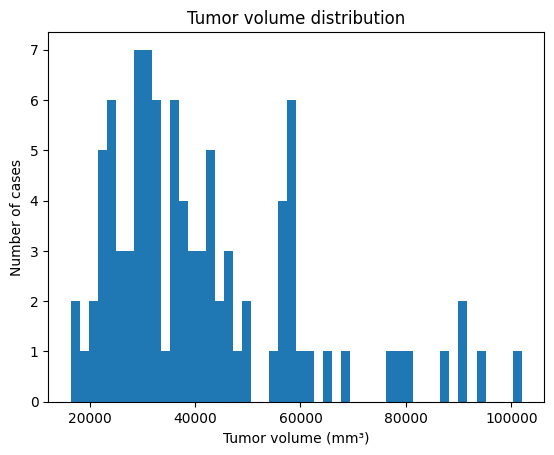

In [ ]:
#distribution of tumor volume across patients
plt.figure()
plt.hist(mri_stats_df["tumor_vol_mm3"].dropna(), bins=50)
plt.xlabel("Tumor volume (mm³)")
plt.ylabel("Number of cases")
plt.title("Tumor volume distribution")
plt.show()

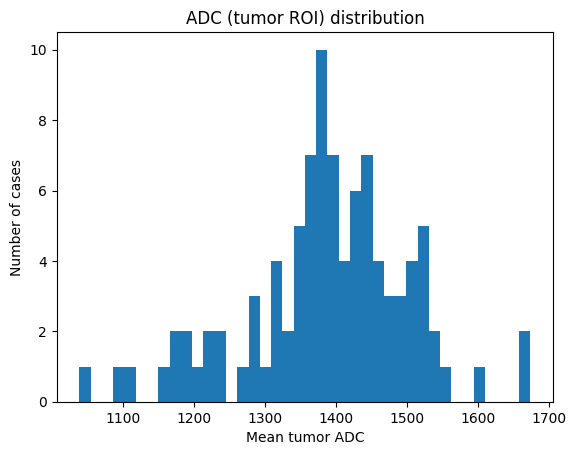

In [ ]:
#plot showing distribuiton of tumor diffusion (ADC)
plt.figure()
plt.hist(mri_stats_df["adc_roi_mean"].dropna(), bins=40)
plt.xlabel("Mean tumor ADC")
plt.ylabel("Number of cases")
plt.title("ADC (tumor ROI) distribution")
plt.show()

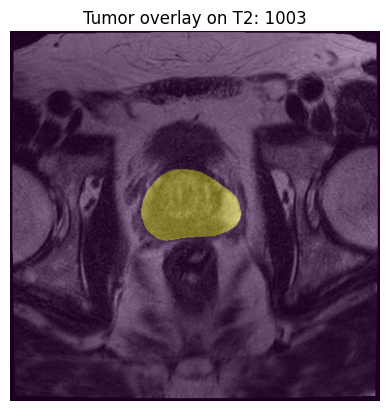

In [52]:
#plotting mask/t2 overlay
#pick case with a non-empty mask
tmp = mri_stats_df.copy()
tmp = tmp[tmp["tumor_voxels"] > 0]
case_id = tmp.iloc[0]["case_id"]
r = cases_df[cases_df["case_id"] == case_id].iloc[0]

#load t2 image and mask
t2_img  = sitk.ReadImage(r["t2w_path"])
msk_img = sitk.ReadImage(r["mask_path"])

t2  = sitk.GetArrayFromImage(t2_img)
msk = sitk.GetArrayFromImage(msk_img)

z = t2.shape[0] // 2 

plt.figure()
plt.imshow(t2[z], cmap="gray")
plt.imshow(msk[z] > 0, alpha=0.4)
plt.title(f"Tumor overlay on T2: {case_id}")
plt.axis("off")
plt.show()
